<a href="https://colab.research.google.com/github/hasselmanneduarda-wq/bioestat-2026/blob/main/Tarefa7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 7 - Semana 4
André Luiz (16854274)
Maria Eduarda S Hasselmann (17100517)
Raissa Lara Pinheiro (16939302)

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import pearsonr
import scipy.stats as stats


Tarefa_Semana4 = pd.read_csv("Tarefa_Semana4.csv", sep="\t")

Tarefa_Semana4.head()

,pH,Biomass,Species
0,high,0.469297,30
1,high,1.730870,39
2,high,2.089778,44
3,high,3.925787,35
4,high,4.366793,25


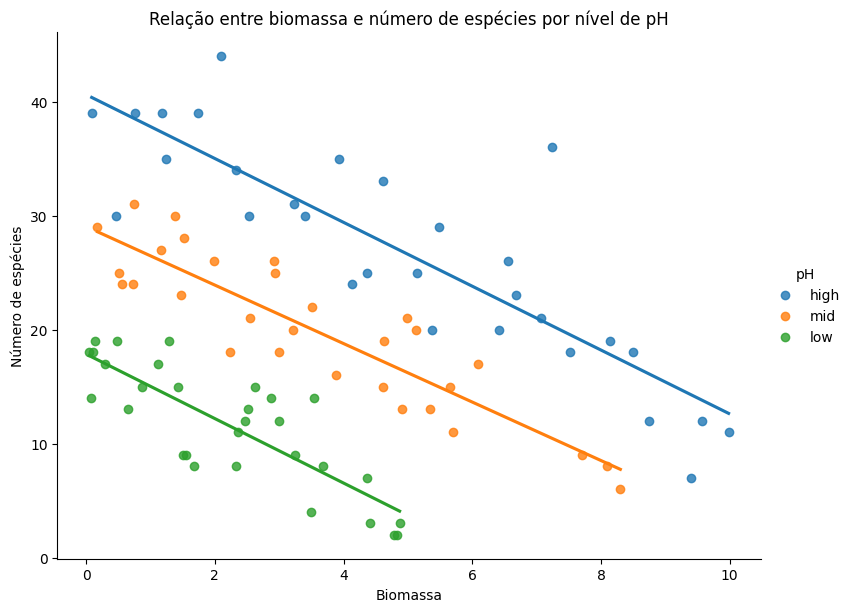

In [114]:
#PERGUNTA 1
sns.lmplot(
    data=Tarefa_Semana4,
    x="Biomass",
    y="Species",
    hue="pH",
    height=6,
    aspect=1.3,
    ci=None
)

plt.xlabel("Biomassa")
plt.ylabel("Número de espécies")
plt.title("Relação entre biomassa e número de espécies por nível de pH")
plt.show()

#Pergunta 1 - Resposta
O gráfico de dispersão mostra a relação entre a quantidade de biomassa e o número de espécies, diferenciando os três níveis de pH. É possível notar que acontece uma tendência negativa entre biomassa e número de espécies. As três categorias de pH apresentam padrões semelhantes, mas diferem principalmente no número médio de espécies.

In [115]:
#PERGUNTA 2
from scipy.stats import pearsonr

r, p = pearsonr(Tarefa_Semana4["Biomass"], Tarefa_Semana4["Species"])

print("Correlação de Pearson:", r)
print("p-valor:", p)

Correlação de Pearson: -0.3171136204583374
p-valor: 0.0023240064396025427


#Pergunta 2 - Resposta
A associação entre biomassa e número de espécies é negativa. A correlação de Pearson foi de aproximadamente −0,317, indicando uma associação negativa de intensidade moderada. Essa associação é estatisticamente significativa (p = 0,0023).

Média de espécies por nível de pH:
pH
high    26.800000
low     11.566667
mid     20.000000
Name: Species, dtype: float64


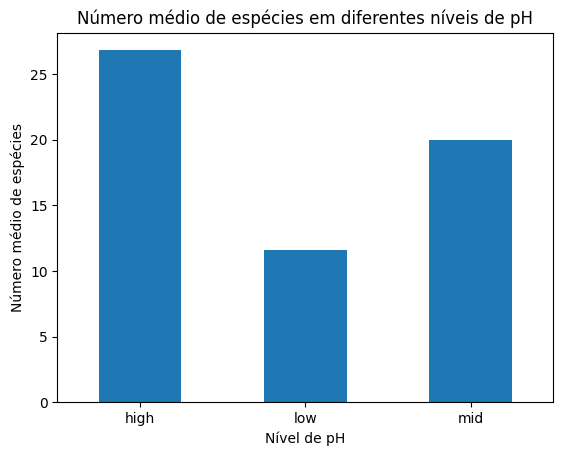

In [116]:
#PERGUNTA 3
medias = Tarefa_Semana4.groupby("pH")["Species"].mean()

print("Média de espécies por nível de pH:")
print(medias)

medias.plot(kind="bar")

plt.xlabel("Nível de pH")
plt.ylabel("Número médio de espécies")
plt.title("Número médio de espécies em diferentes níveis de pH")
plt.xticks(rotation=0)
plt.show()

# Pergunta 3 - Resposta
Existe uma certa evidência entre o efeito do pH sobre o número de espécies. As áreas com pH alto apresentaram, em média, 26,8 espécies, as de pH médio 20,0 espécies e as de pH baixo 11,57 espécies. Sendo assim, o número de espécies aumenta à medida que passamos de um pH mais baixo para o médio e para o alto.

In [117]:
#PERGUNTA 4
freq_ph = Tarefa_Semana4["pH"].value_counts()

freq_ph
freq_ph = Tarefa_Semana4["pH"].value_counts()

freq_ph.reindex(["low", "mid", "high"])

,count
pH,
low,30
mid,30
high,30


#Pergunta 4 - Resposta
É possível utilizar um modelo de regressão linear simples para tentar prever o número de espécies a partir do valor da biomassa. O modelo apresentou uma relação negativa entre as variáveis.

In [118]:
#PERGUNTA 5
freq_ph = Tarefa_Semana4["pH"].value_counts()
freq_ph = freq_ph.reindex(["low", "mid", "high"])

tabela_freq_ph = freq_ph.reset_index()
tabela_freq_ph.columns = ["Nível de pH", "Frequência"]
tabela_freq_ph["Nível de pH"] = tabela_freq_ph["Nível de pH"].map({
    "low": "Baixo", "mid": "Médio", "high": "Alto"
})
tabela_freq_ph["Proporção (%)"] = (tabela_freq_ph["Frequência"] / tabela_freq_ph["Frequência"].sum() * 100).round(1)

tabela_freq_ph

,Nível de pH,Frequência,Proporção (%)
0,Baixo,30,33.3
1,Médio,30,33.3
2,Alto,30,33.3


#Pergunta 5 - Resposta
Como o pH é uma variável categórica ele foi analisado como um fator, usando o pH alto como uma categoria de referência. O número estimado de espécies foi de 26,80 (pH alto), 20,00 (pH médio) e 11,57 (pH baixo).

In [119]:
#PERGUNTA 6
tabela_intercepto = pd.DataFrame({
    "Intercepto estimado": [round(modelo_biomassa.params['Intercept'], 3)],
    "Interpretação": ["Número esperado de espécies quando a biomassa = 0"]
})
tabela_intercepto

,Intercepto estimado,Interpretação
0,23.676,Número esperado de espécies quando a biomassa = 0


In [120]:
print(modelo_biomassa.params["Intercept"])

23.675543953867273


#Pergunta 6 - Resposta
O valor do intercepto estimado é 23,676. Isso significa que quando a biomassa é igual a zero, o número esperado de espécies é aproximadamente 23,68.

In [121]:
#PERGUTA 7
tabela_slope = pd.DataFrame({
    "Coeficiente de inclinação (slope)": [round(modelo_biomassa.params['Biomass'], 3)],
    "Interpretação": [f"Para cada unidade adicional de biomassa, o número esperado de espécies "
                       f"muda em {modelo_biomassa.params['Biomass']:.3f} unidades"]
})
tabela_slope

,Coeficiente de inclinação (slope),Interpretação
0,-1.186,"Para cada unidade adicional de biomassa, o núm..."


#Pergunta 7 - Resposta
O coeficiente de inclinação é −1,186. Isso indica que para cada aumento de uma unidade na biomassa, o número esperado de espécies diminui em aproximadamente 1,19 espécies.

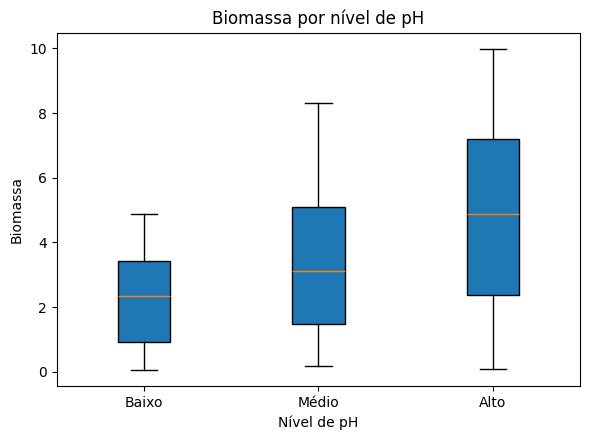

In [122]:
#PERGUNTA 8
plt.figure(figsize=(6, 4.5))
data_box2 = [Tarefa_Semana4[Tarefa_Semana4['pH'] == g]['Biomass'] for g in ['low', 'mid', 'high']]
plt.boxplot(data_box2, tick_labels=['Baixo', 'Médio', 'Alto'], patch_artist=True)
plt.xlabel('Nível de pH')
plt.ylabel('Biomassa')
plt.title('Biomassa por nível de pH')
plt.tight_layout()
plt.show()

#Pergunta 8 - Resposta
Sim. A biomassa apresenta efeito estatisticamente significativo sobre o número de espécies (p = 0,0023), indicando evidência de uma relação entre as duas variáveis.

In [123]:
#PERGUNTA 9
tabela_r2_ph = pd.DataFrame({
    "R² (Species ~ pH)": [round(modelo_anova.rsquared, 3)],
    "% da variação explicada": [f"{modelo_anova.rsquared*100:.1f}%"]
})
tabela_r2_ph

,R² (Species ~ pH),% da variação explicada
0,0.419,41.9%


#Pergunta 9 - Resposta
O pH explica 41,9% da variação observada no número de espécies. Isso indica que as diferenças entre os grupos de pH estão associadas a uma média parcela da variação no número de espécies.

In [124]:

#PERGUNTA 10
r_bio, p_bio = stats.pearsonr(Tarefa_Semana4['Biomass'], Tarefa_Semana4['Species'])

tabela_corr10 = pd.DataFrame({
    "Correlação de Pearson (r)": [round(r_bio, 4)],
    "p-valor": [round(p_bio, 5)],
    "Significativa (p<0,05)": ["Sim" if p_bio < 0.05 else "Não"]
})
tabela_corr10

,Correlação de Pearson (r),p-valor,"Significativa (p<0,05)"
0,-0.3171,0.00232,Sim


#Pergunta 10 - Resposta
Existe correlação linear significativa entre biomassa e número de espécies. A correlação de Pearson foi −0,317, indicando uma relação negativa e estatisticamente significativa (p = 0,0023).

In [125]:
#PERGUNTA 11
ph_map = {'low': 1, 'mid': 2, 'high': 3}
Tarefa_Semana4['pH_ord'] = Tarefa_Semana4['pH'].map(ph_map)
r_ph, p_ph = stats.pearsonr(Tarefa_Semana4['pH_ord'], Tarefa_Semana4['Species'])

tabela_corr_ph = pd.DataFrame({
    "Correlação de Pearson (r)": [round(r_ph, 4)],
    "p-valor": ["{:.2e}".format(p_ph)],
    "Direção": ["Positiva" if r_ph > 0 else "Negativa"],
    "Intensidade": ["Forte" if abs(r_ph) > 0.5 else "Fraca/Moderada"]
})
tabela_corr_ph

,Correlação de Pearson (r),p-valor,Direção,Intensidade
0,0.6461,6.11e-12,Positiva,Forte


# Pergunta 11 - Resposta
 A correlação linear de Pearson entre pH e o número de espécies é forte e positiva (r = 0.6461).


In [126]:
resultados_grupo = {}
for g in ['low', 'mid', 'high']:
    sub = Tarefa_Semana4[Tarefa_Semana4['pH'] == g]
    r, p_val = stats.pearsonr(sub['Biomass'], sub['Species'])
    Xg = sm.add_constant(sub['Biomass'])
    mg = sm.OLS(sub['Species'], Xg).fit()
    resultados_grupo[g] = {'r': r, 'p': p_val, 'intercepto': mg.params['const'],
                           'slope': mg.params['Biomass'], 'R2': mg.rsquared}

tabela_grupos_ph = pd.DataFrame(resultados_grupo).T.reindex(['low', 'mid', 'high'])
tabela_grupos_ph = tabela_grupos_ph.reset_index()
tabela_grupos_ph.columns = ["pH", "r", "p-valor", "Intercepto", "Slope", "R²"]
tabela_grupos_ph["pH"] = tabela_grupos_ph["pH"].map({"low": "Baixo", "mid": "Médio", "high": "Alto"})
tabela_grupos_ph = tabela_grupos_ph.round(4)
tabela_grupos_ph

,pH,r,p-valor,Intercepto,Slope,R²
0,Baixo,-0.8256,0.0,17.8474,-2.8278,0.6816
1,Médio,-0.8932,0.0,29.0310,-2.5651,0.7979
2,Alto,-0.8619,0.0,40.6041,-2.8005,0.7428


In [127]:
modelo_ancova = smf.ols('Species ~ Biomass + C(pH)', data=Tarefa_Semana4).fit()

tabela_ancova = pd.DataFrame({
    "Coeficiente": modelo_ancova.params.values,
    "Erro Padrão": modelo_ancova.bse.values,
    "t": modelo_ancova.tvalues.values,
    "p-valor": modelo_ancova.pvalues.values
}, index=modelo_ancova.params.index)

tabela_ancova["R²"] = modelo_ancova.rsquared
tabela_ancova

,Coeficiente,Erro Padrão,t,p-valor,R²
Intercept,40.244865,1.092330,36.843137,1.888182e-54,0.852375
C(pH)[T.low],-22.620022,1.081834,-20.908952,1.789533e-35,0.852375
C(pH)[T.mid],-10.641835,1.006325,-10.574953,3.136781e-17,0.852375
Biomass,-2.727580,0.171672,-15.888296,2.577862e-27,0.852375
